In [1]:
import os

PROJECT_PATH = '/home/sbehnam/Project/grasp2sim'
SCENE_DIR = os.path.join(PROJECT_PATH, 'scenes')
POSES_DIR = os.path.join(PROJECT_PATH, 'poses')

import sys
sys.path.append(PROJECT_PATH)

os.environ['MUJOCO_GL'] = 'egl'

import mujoco
import mediapy as media
import numpy as np
from tqdm import tqdm
from scipy.spatial.transform import Rotation as R

In [2]:
from scenes.grasp2scene import Scene, GRASPNET_SCENE_ROOT, MODEL_DIR, HAND_ASSETS

object_id = 5

XML_PATH = f'{SCENE_DIR}/scene_{object_id}-2_0000.xml'

s = Scene(scene_dir=GRASPNET_SCENE_ROOT, model_dir=MODEL_DIR, hand_assets=HAND_ASSETS)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
s.save_xml(XML_PATH, obj_indexes=object_id)

Saved → /home/sbehnam/Project/grasp2sim/scenes/scene_5-2_0000.xml


In [4]:
from grasp_sim import GraspHand, Executors

hand = GraspHand(grasps_npy="/home/sbehnam/Project/data/scenes/scene_0000/some_banana_grasp.npy", debug=True,
                  debug_log_every=1)
hand.reset_scene()
# hand.step(30)
hand.capture()

media.show_video(hand.frames, fps=8)

In [ ]:
from graspnetAPI import GraspGroup
import copy

def filter_by_object_id(grasps_group : GraspGroup, object_id) -> GraspGroup:

    filtered_grasp_group_array = copy.deepcopy(grasps_group.grasp_group_array)

    filter_grasp_group = GraspGroup(filtered_grasp_group_array[filtered_grasp_group_array[:, 16] == object_id])

    return filter_grasp_group

one_object_grasps = filter_by_object_id(hand.gg, 5)

sample_pose = GraspGroup()

sample_pose.grasp_group_array = one_object_grasps.grasp_group_array[2:3]

sample_pose

----------
Grasp Group, Number=1:
Grasp: score:0.7000000476837158, width:0.04720092937350273, height:0.019999999552965164, depth:0.009999999776482582, translation:[-0.10236878 -0.08849756  0.45573398]
rotation:
[[-0.12598054 -0.99199384  0.00877897]
 [-0.71744215  0.08499432 -0.69141352]
 [ 0.68513179 -0.09340308 -0.72240585]]
object id:5
----------

In [6]:
from graspnetAPI import GraspNet

GRAPNET_DATASET = "/home/sbehnam/Project/data/"

g_net = GraspNet(root=GRAPNET_DATASET, camera='kinect', split='custom', sceneIds=[0])
cloud = g_net.loadScenePointCloud(sceneId=0, camera='kinect', annId=0, align=False)

Loading data path...: 100%|██████████| 1/1 [00:00<00:00, 343.63it/s]


[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x58a38562c7d0 (threading is enabled)
EGL(1.5)
OpenGL(4.1)


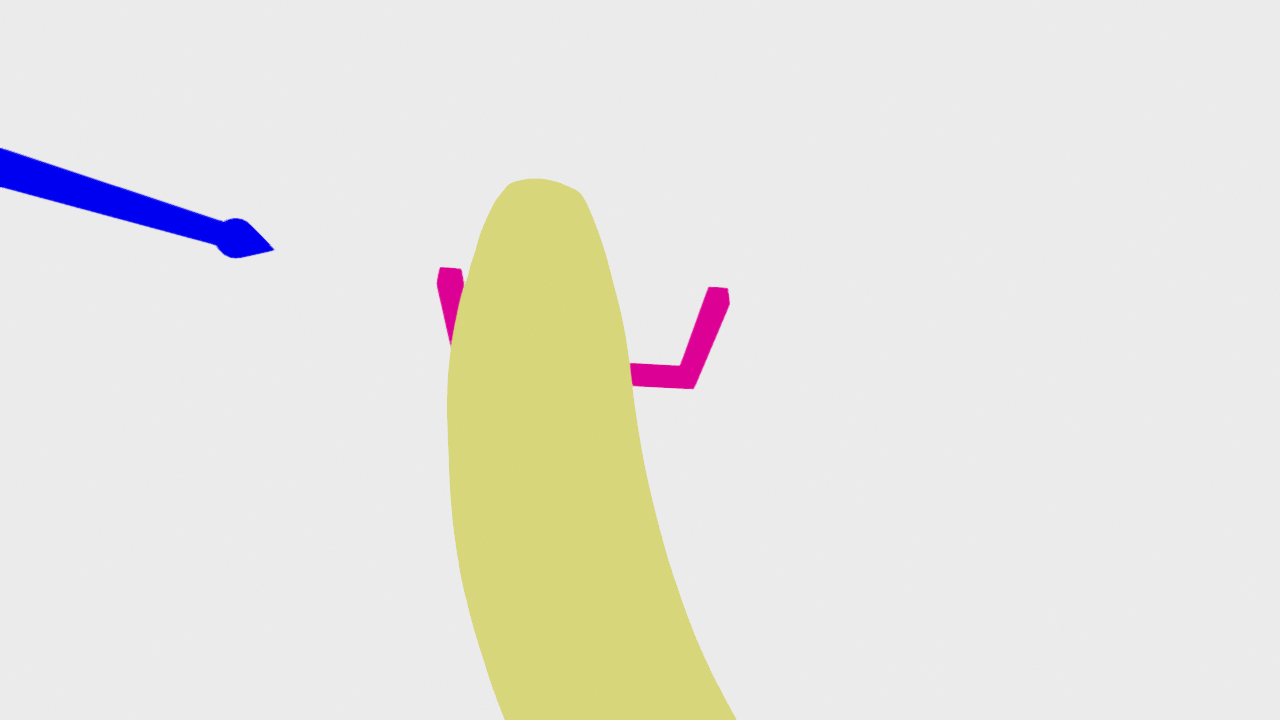

In [9]:
import open3d as o3d
from poses.publisher import render_geometries_to_notebook

mesh = o3d.io.read_triangle_mesh("/home/sbehnam/models/005/nontextured.stl")
mesh.compute_vertex_normals()
mesh.paint_uniform_color([0.7, 0.7, 0.2])

from graspnetAPI.utils.utils import parse_posevector

for pv in s.posevectors:

    obj_idx, obj_pose_cam = parse_posevector(pv)
    if obj_idx == object_id:
        mesh.transform(s.camera_pose @ obj_pose_cam)
        break;

# Table coordinate frame for reference
frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1)

sample_pose.transform(s.camera_pose)
grippers = sample_pose.to_open3d_geometry_list()

render_geometries_to_notebook([frame, mesh] + grippers) 

[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x5710354b9f00 (threading is enabled)
EGL(1.5)
OpenGL(4.1)


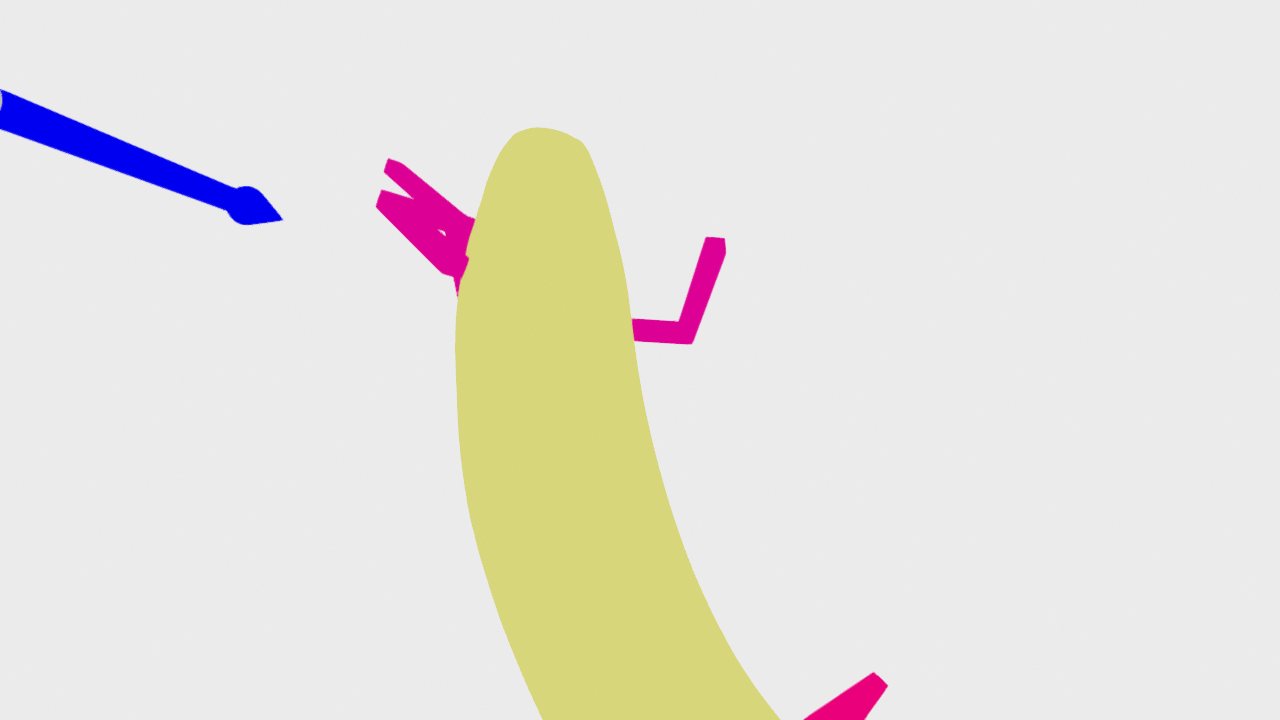

In [ ]:
import open3d as o3d
from graspnetAPI import GraspGroup
from graspnetAPI.utils.xmlhandler import xmlReader
from graspnetAPI.utils.utils import parse_posevector
from poses.publisher import render_geometries_to_notebook

CAMERA = 'kinect'  # try both 'kinect' and 'realsense'
scene_dir = f'/home/sbehnam/Project/data/scenes/scene_0000/{CAMERA}'

T_CAM2TABLE = np.load(f'{scene_dir}/cam0_wrt_table.npy') @ np.load(f'{scene_dir}/camera_poses.npy')[0]

# Mesh in table frame
mesh = o3d.io.read_triangle_mesh('/home/sbehnam/models/005/textured.obj')
pvs = xmlReader(f'{scene_dir}/annotations/0000.xml').getposevectorlist()
for pv in pvs:
    oid, pose_cam = parse_posevector(pv)
    if oid == 5:
        mesh.transform(T_CAM2TABLE @ pose_cam)
        break
mesh.paint_uniform_color([0.7, 0.7, 0.2])

# Grasps in table frame
gg = GraspGroup(np.load('/home/sbehnam/Project/data/scenes/scene_0000/some_banana_grasp.npy'))
gg.transform(T_CAM2TABLE)
grippers = gg[:5].to_open3d_geometry_list()

# Table coordinate frame for reference
frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1)

render_geometries_to_notebook([frame, mesh] + grippers)

In [9]:
def render_geometries_to_notebook(
    geometries,
    width=1280, height=720,
    view='top',           # 'top', 'front', 'side', 'iso', or custom
    zoom=1.2,             # >1 zooms out, <1 zooms in
    shift=(0, 0, 0),      # nudge the look-at point
    bg=(1, 1, 1, 1),
    save_path="scene.png",
    show_axes=True,
):
    import open3d as o3d
    from IPython.display import Image

    renderer = o3d.visualization.rendering.OffscreenRenderer(width, height)
    renderer.scene.set_background(list(bg))

    mat = o3d.visualization.rendering.MaterialRecord()
    mat.shader = "defaultUnlit"

    geoms_to_render = list(geometries)
    if show_axes:
        # 10 cm axes at world origin (red=X, green=Y, blue=Z)
        geoms_to_render.append(
            o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1)
        )

    for i, g in enumerate(geoms_to_render):
        renderer.scene.add_geometry(f"geom_{i}", g, mat)

    # bounds from the actual scene contents (not axes)
    bounds = o3d.geometry.AxisAlignedBoundingBox()
    for g in geometries:
        bounds += g.get_axis_aligned_bounding_box()
    center = bounds.get_center() + np.array(shift)
    diag = np.linalg.norm(bounds.get_extent())
    dist = diag * zoom

    # Common camera presets (table-frame conventions: Z up)
    presets = {
        'top':   (np.array([0, 0,  dist]), np.array([0, 1, 0])),
        'front': (np.array([0, -dist, 0]), np.array([0, 0, 1])),
        'side':  (np.array([dist, 0, 0]),  np.array([0, 0, 1])),
        'iso':   (np.array([dist, -dist, dist]) * 0.6, np.array([0, 0, 1])),
    }
    eye_offset, up = presets.get(view, presets['iso'])
    eye = center + eye_offset

    renderer.setup_camera(
        60.0,
        center.astype(np.float32),
        eye.astype(np.float32),
        up.astype(np.float32),
    )

    img = renderer.render_to_image()
    o3d.io.write_image(save_path, img)
    return Image(save_path)

[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x5710354b9f00 (threading is enabled)
EGL(1.5)
OpenGL(4.1)


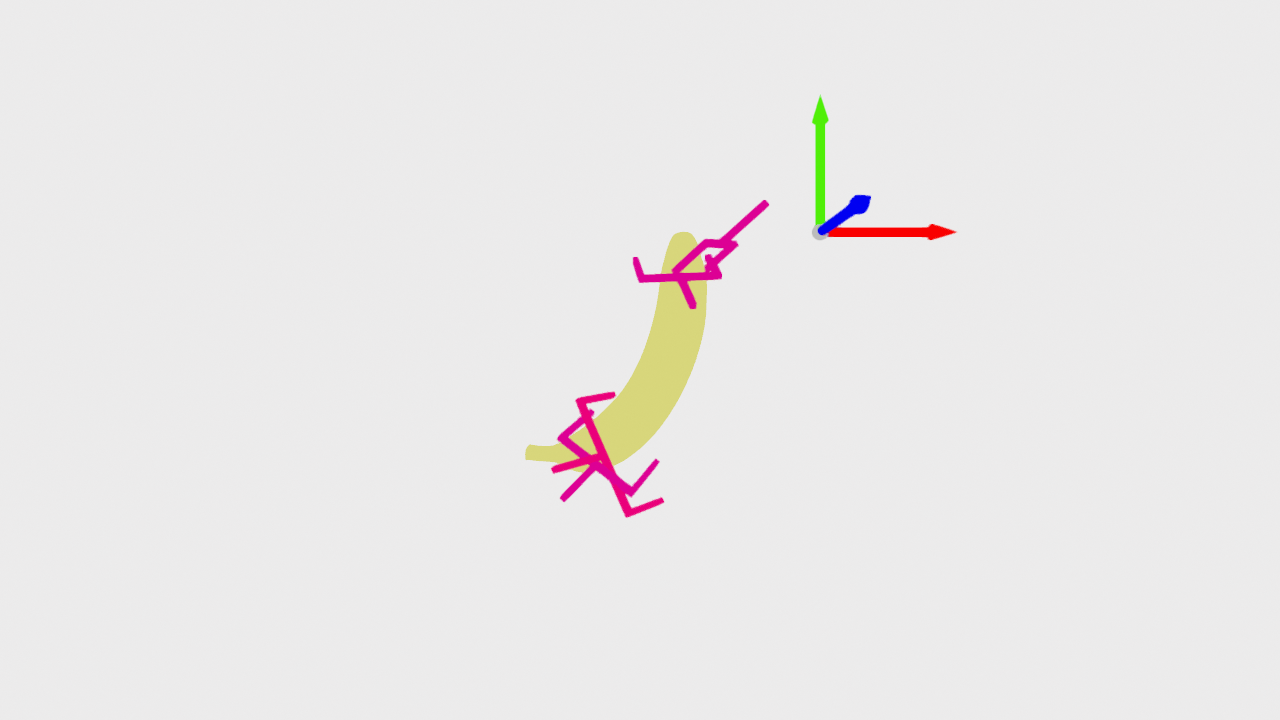

In [10]:
render_geometries_to_notebook([mesh, *grippers], view='top', zoom=1.5)

[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x596d09a6c700 (threading is enabled)
EGL(1.5)
OpenGL(4.1)


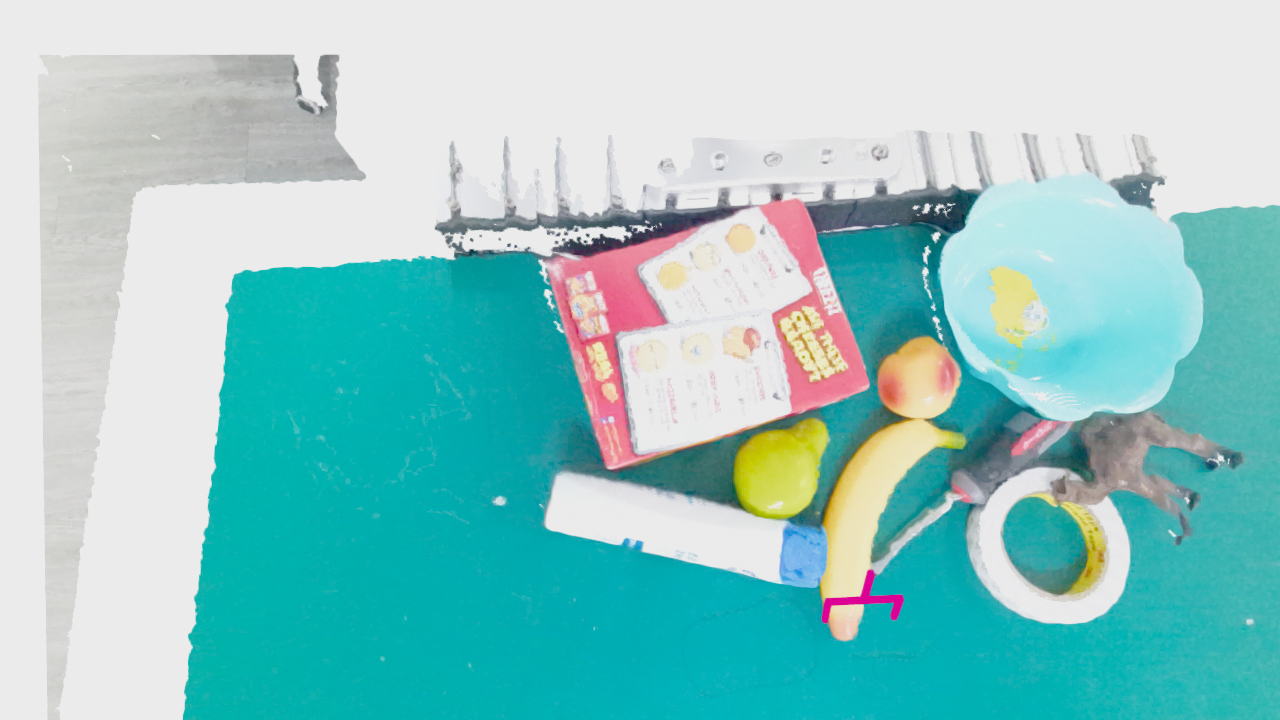

In [ ]:
from poses.publisher import render_geometries_to_notebook

geometries = []
geometries.append(cloud)
geometries += sample_pose.to_open3d_geometry_list()
render_geometries_to_notebook(geometries, width=1280, height=720, shift_x=-0.2)

In [ ]:

# import open3d as o3d

# combined = o3d.geometry.PointCloud()

# for geom in geometries:
#     if isinstance(geom, o3d.geometry.PointCloud):
#         combined += geom
#     elif isinstance(geom, o3d.geometry.TriangleMesh):
#         combined += geom.sample_points_uniformly(number_of_points=1000)

# o3d.io.write_point_cloud('debug_combined_5.ply', combined)

# o3d.io.write_point_cloud("/home/sbehnam/Project/grasp2sim/scene_some_banana.ply", combined)

True

In [6]:
hand.frames = []

hand.cam.azimuth = -120
hand.cam.distance = 0.5
hand.cam.lookat = [-0.2, -0.15, 0]

g          = sample_pose[0]
t_w        = hand.grasp_to_world(g)

quat       = hand.to_mujoco_quat(g.rotation_matrix)
approach_w = hand.T_CAM2TABLE[:3, :3] @ g.rotation_matrix[:, 0]

theo_mid_cam = g.translation + g.depth * g.rotation_matrix[:, 0]
theo_mid = hand.T_CAM2TABLE[:3, :3] @ theo_mid_cam + hand.T_CAM2TABLE[:3, 3]

# ---

m_tw   = mujoco.mj_name2id(hand.model, mujoco.mjtObj.mjOBJ_BODY, "marker_tw")
m_theo = mujoco.mj_name2id(hand.model, mujoco.mjtObj.mjOBJ_BODY, "marker_theo")

hand.reset_scene()

hand.sim.mocap_pos[hand.model.body_mocapid[m_tw]]   = t_w
hand.sim.mocap_pos[hand.model.body_mocapid[m_theo]] = theo_mid
mujoco.mj_forward(hand.model, hand.sim)
hand.capture()

media.show_video(hand.frames, fps=3)

In [7]:
from grasp_sim import Executors

hand_id = mujoco.mj_name2id(hand.model, mujoco.mjtObj.mjOBJ_BODY, "hand")
left_tip_site_id  = hand.model.site("left_tip").id
right_tip_site_id = hand.model.site("right_tip").id

t_w        = hand.grasp_to_world(g)

quat       = hand.to_mujoco_quat(g.rotation_matrix)
approach_w = hand.T_CAM2TABLE[:3, :3] @ g.rotation_matrix[:, 0]

# hand.reset_scene()
# hand.open_gripper(min(0.08, g.width + 0.015))   # small slack
hand.open_gripper(0.2)  # open wide for visualization
hand.step(30)
hand.capture()

pre_grasp_pose = t_w - 0.12 * approach_w

hand.move_hand(pre_grasp_pose, quat, n_steps=200, record=True)

hand.move_hand(t_w, quat, n_steps=100, record=True, substeps=8)

hand.close_gripper()
hand.step(200, record=True)

hand.move_hand(pre_grasp_pose, quat, n_steps=200, record=True)

hand.move_hand(pre_grasp_pose + np.array([0.0, 0.0, 0.25]), quat,
                      n_steps=200, record=True)

# intended vs actual
print(f"target  t_w = {np.round(t_w,4)}")
print(f"actual hand = {np.round(hand.sim.xpos[hand_id],4)}")

# compute actual fingertip midpoint in world
tipL = hand.sim.site_xpos[left_tip_site_id]   # or xpos of left pad body
tipR = hand.sim.site_xpos[right_tip_site_id]
actual_mid = 0.5*(tipL + tipR)

# theoretical fingertip midpoint from GraspNet
theo_mid_cam = g.translation + g.depth * g.rotation_matrix[:, 0]
theo_mid = hand.T_CAM2TABLE[:3, :3] @ theo_mid_cam + hand.T_CAM2TABLE[:3, 3]

print(f"actual mid  = {np.round(actual_mid,4)}")
print(f"theo   mid  = {np.round(theo_mid,4)}")
print(f"error       = {np.linalg.norm(actual_mid - theo_mid)*1000:.1f} mm")

media.show_video(hand.frames, fps=3)

target  t_w = [-0.0935 -0.0801  0.1097]
actual hand = [-0.0775 -0.1432  0.4605]
actual mid  = [-0.0912 -0.0891  0.3741]
theo   mid  = [-0.1082 -0.0215  0.0162]
error       = 364.7 mm


This browser does not support the video tag.
